## Exploratory Data Analysis (EDA)

This project analyzes air quality data collected from 12 monitoring stations in Beijing, China, covering the period from 2013 to 2017. The dataset contains hourly measurements of air pollutants and meteorological conditions.

The analysis focuses on six major air pollutants: PM2.5, PM10, SO2, NO2, CO, and O3. The project examines their concentrations, distributions, changes over time, differences among monitoring stations, and relationships between pollutants.

## 1. Import Libraries

The required Python libraries are imported for data manipulation, visualization, and database connectivity.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

## 2. Connect to Database

Connect Python to the MySQL database containing the air quality datasets.

In [14]:
regions_file = "../PRSA_Data_20130301-20170228/regions.csv"

combined_df = pd.read_csv(regions_file)

print("Total records:", len(combined_df))

Total records: 420768


In [20]:
combined_df.head()


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,date
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01


In [ ]:
missing_values = combined_df.isnull().sum()

print(missing_values)

No             0
year           0
month          0
day            0
hour           0
PM2.5       8739
PM10        6449
SO2         9021
NO2        12116
CO         20701
O3         13277
TEMP         398
PRES         393
DEWP         403
RAIN         390
wd          1822
WSPM         318
station        0
date           0
dtype: int64


## 3. Defining Pollutants

Six major air pollutants are selected for the analysis: PM2.5, PM10, SO2, NO2, CO, and O3. These variables represent different types of air pollution and are used throughout the statistical analysis and visualization sections.

In [ ]:
pollutants = [
    "PM2.5",
    "PM10",
    "SO2",
    "NO2",
    "CO",
    "O3"
]

print("Pollutants included in the analysis:")
print(pollutants) 

pollutant_statistics = combined_df[pollutants].describe()

pollutant_statistics

Pollutants included in the analysis:
['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']


,PM2.5,PM10,SO2,NO2,CO,O3
count,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000
mean,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271
std,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607
min,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200
25%,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000
50%,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000
75%,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000
max,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000


## 4. Graph 1: Average Pollutant Concentration

The average concentration of each pollutant is calculated for every monitoring station. The visualization allows the pollutant levels to be compared across the 12 stations.

Separate graphs are used for each pollutant because the pollutants have different measurement scales and units. This makes the differences between stations easier to interpret.

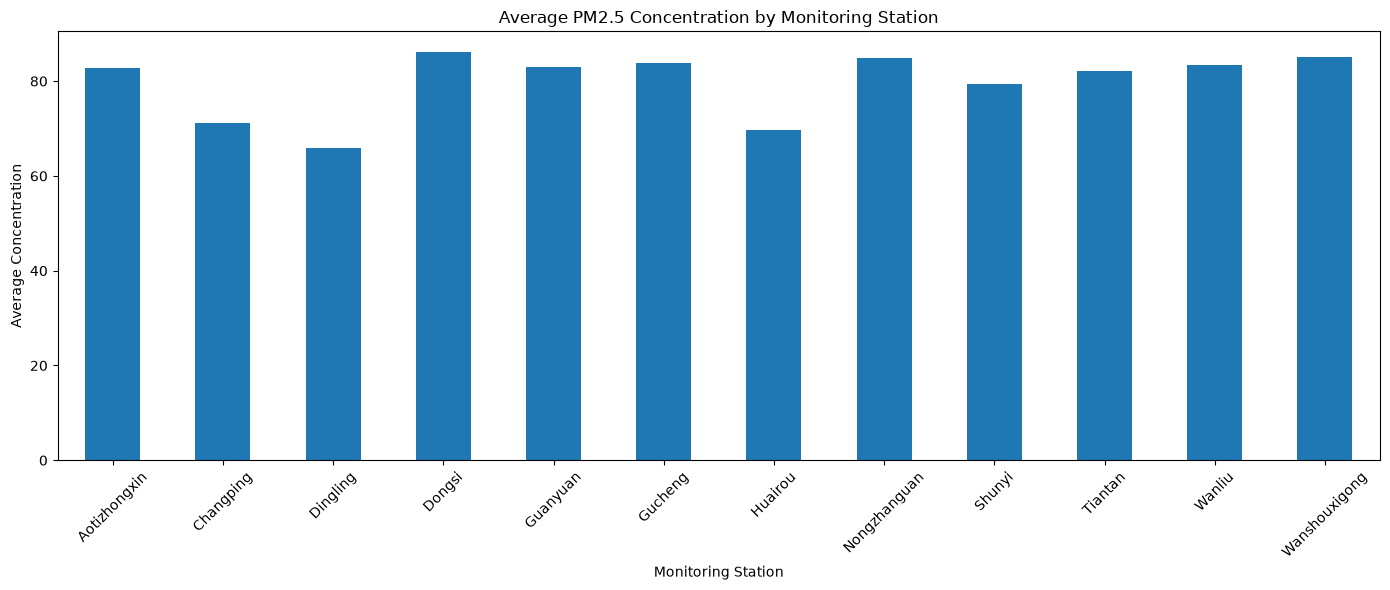

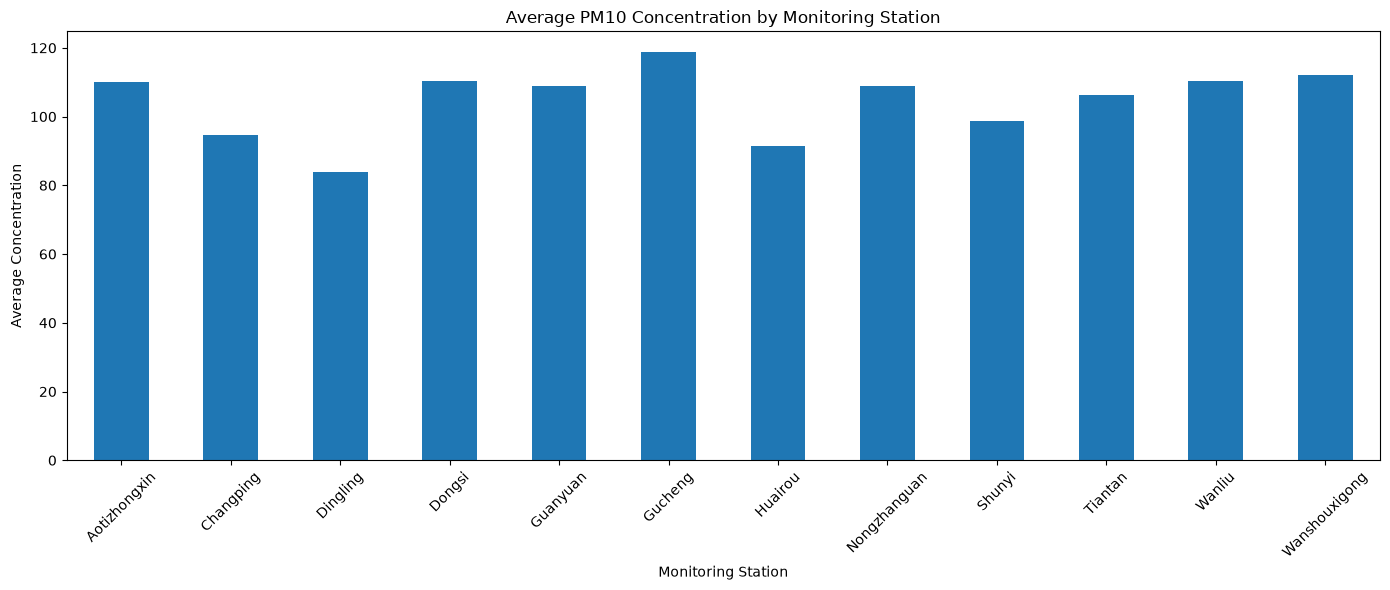

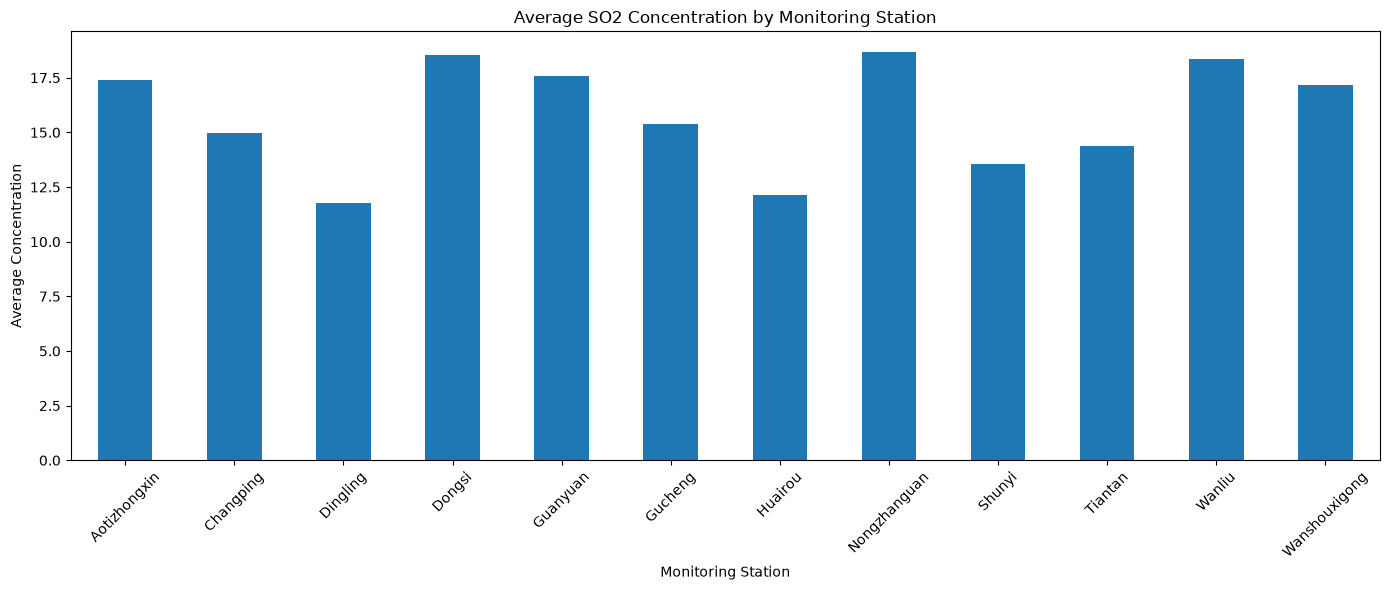

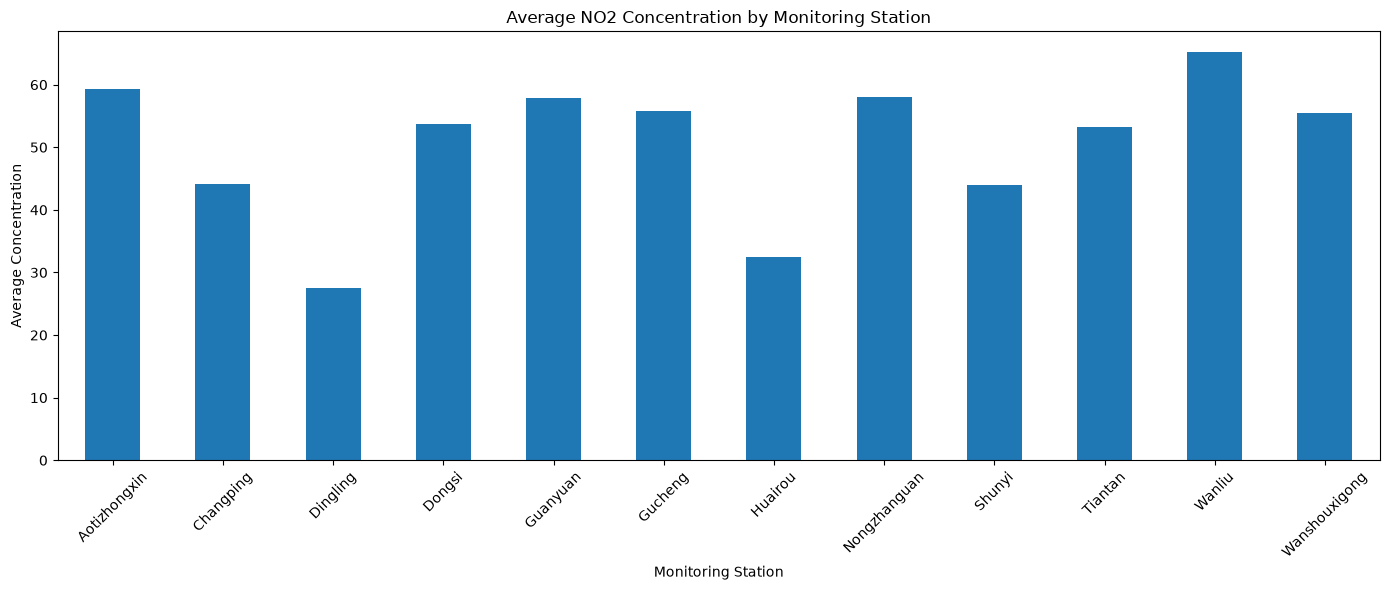

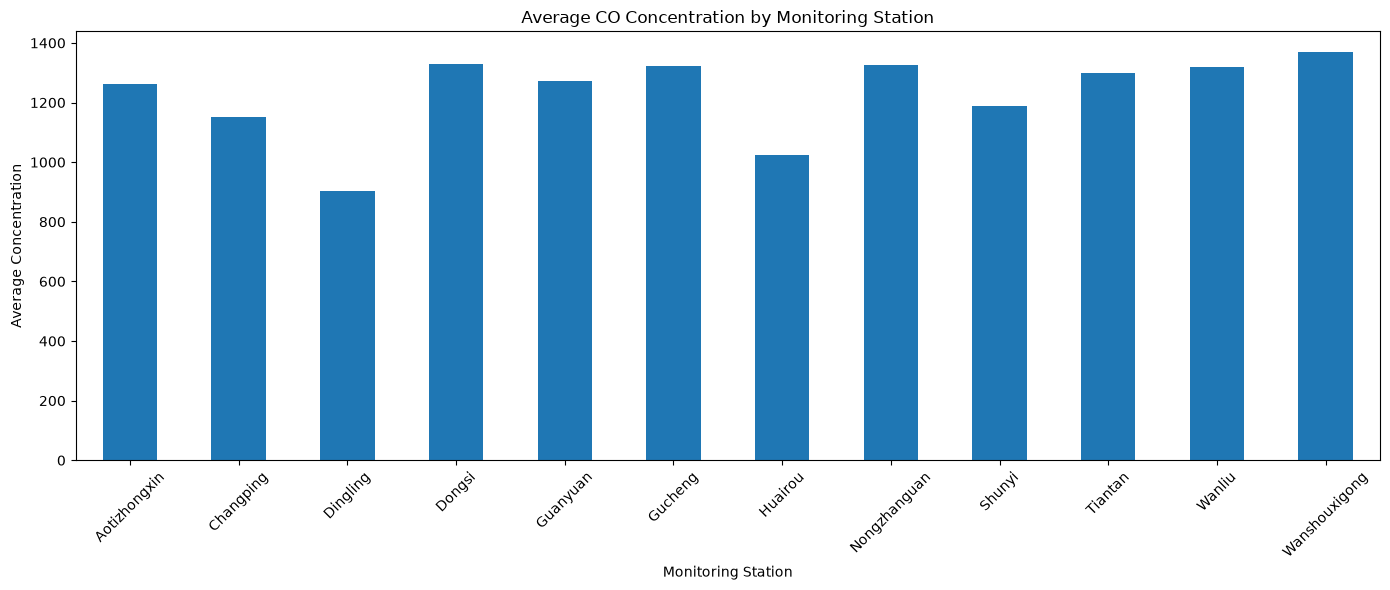

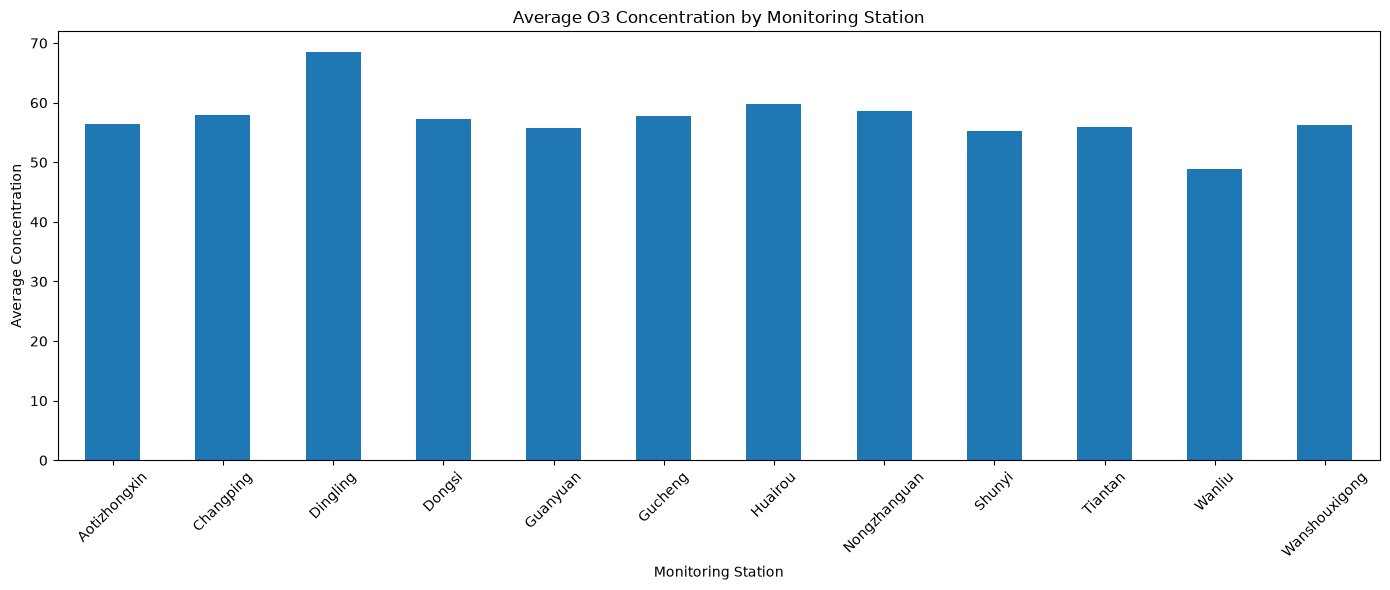

In [ ]:
station_averages = combined_df.groupby("station")[pollutants].mean()

station_averages

for pollutant in pollutants:

    ax = station_averages[pollutant].plot(
        kind="bar",
        figsize=(14, 6)
    )

    ax.set_title(
        f"Average {pollutant} Concentration by Monitoring Station"
    )

    ax.set_xlabel("Monitoring Station")
    ax.set_ylabel("Average Concentration")
    ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

### Analysis

The graph shows how the average concentration of the selected pollutant differs among the 12 monitoring stations. Differences between stations may indicate variations in local pollution conditions and surrounding environmental factors.

The station with the highest average value represents the location with the highest recorded average concentration for that pollutant, while the station with the lowest value represents the lowest average concentration.

## 5. Graph 2: Daily Average of Pollutants from across 12 monitoring station

Daily averages are calculated for the six pollutants using observations from the 12 monitoring stations. The graphs show how pollutant concentrations change from day to day throughout the study period.

This visualization helps identify fluctuations, periods of increased concentration, and general changes in pollutant levels over time.

In [ ]:
daily_pollutants = (
    combined_df
    .groupby("date")[pollutants]
    .mean()
)

daily_pollutants.head()

,PM2.5,PM10,SO2,NO2,CO,O3
date,,,,,,
2013-03-01,7.326389,12.255245,9.280142,21.405738,406.737589,68.485816
2013-03-02,31.475694,40.616725,32.007989,56.704889,948.367491,32.578817
2013-03-03,79.291667,111.104167,49.386760,77.021429,1773.306620,22.788194
2013-03-04,21.731449,40.601399,18.805865,43.134273,727.923077,56.833333
2013-03-05,132.439114,159.236111,71.333333,104.256506,2047.232143,79.527778


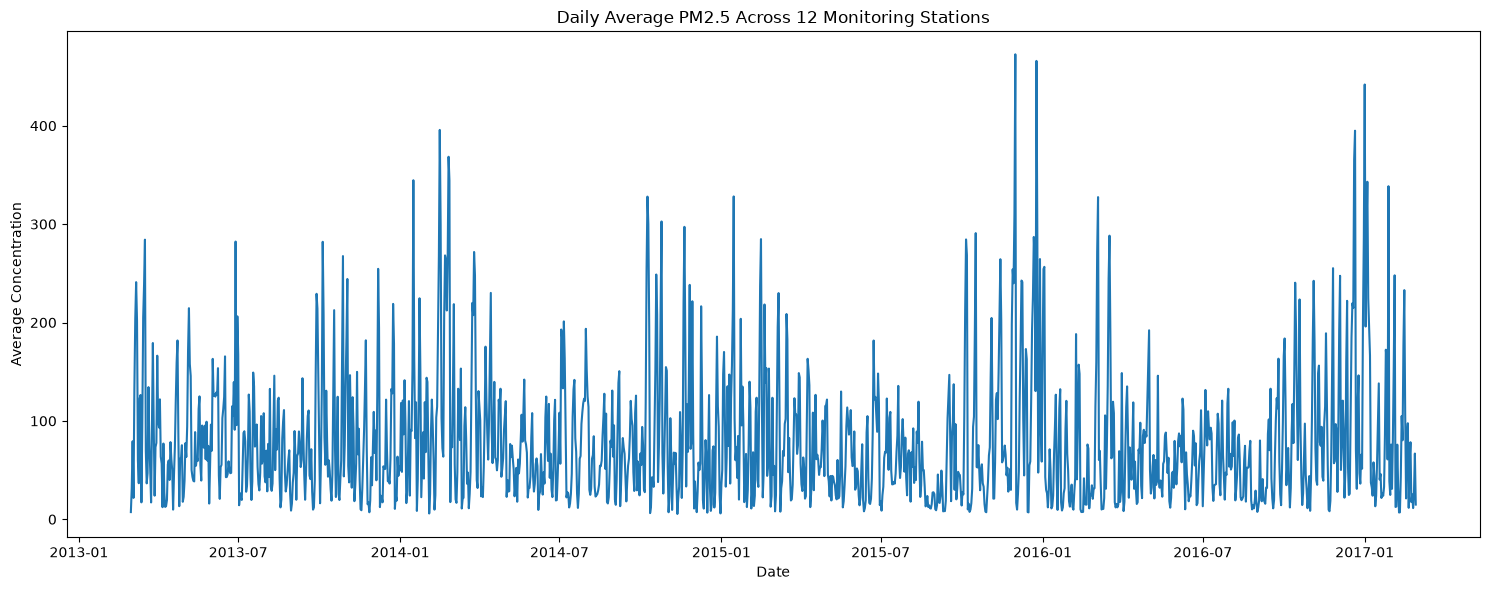

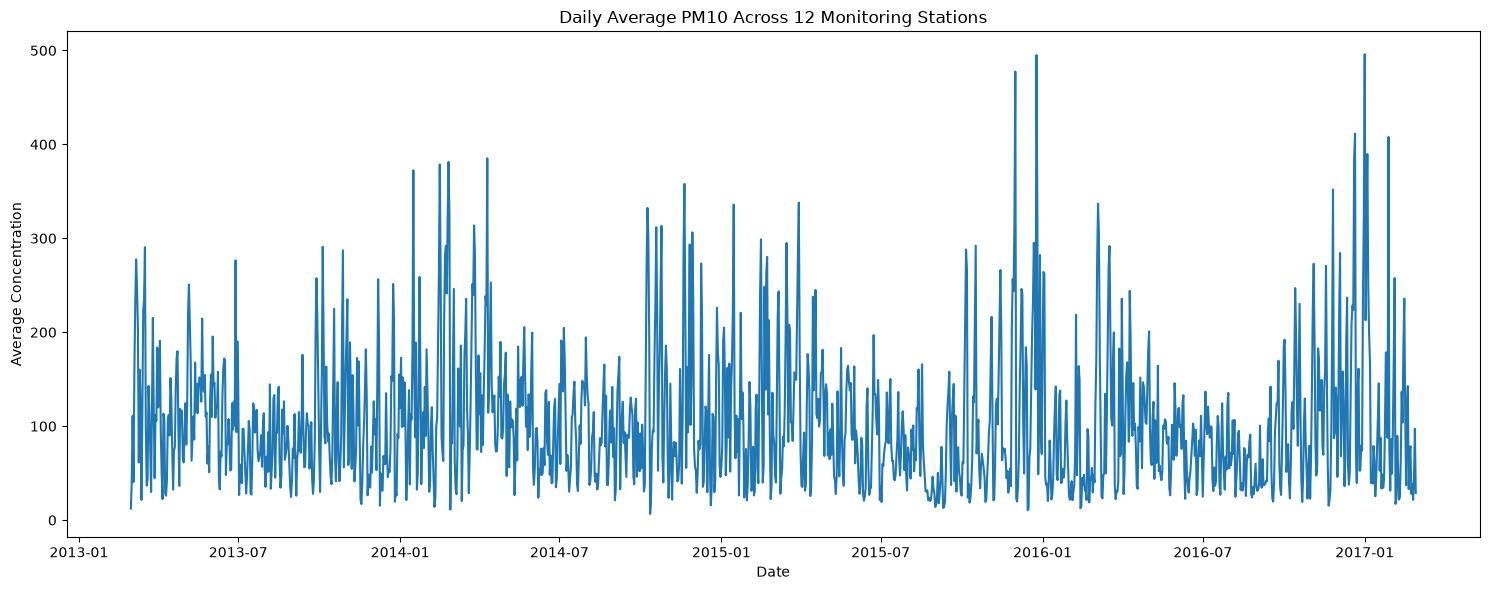

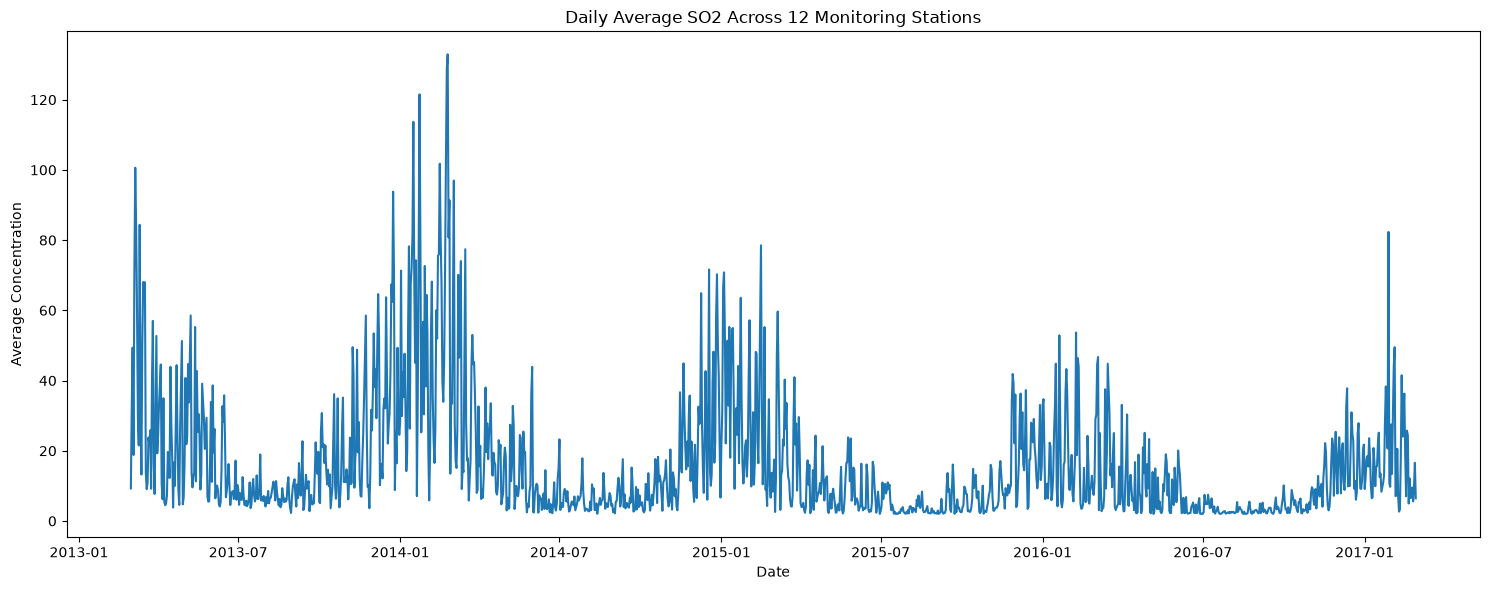

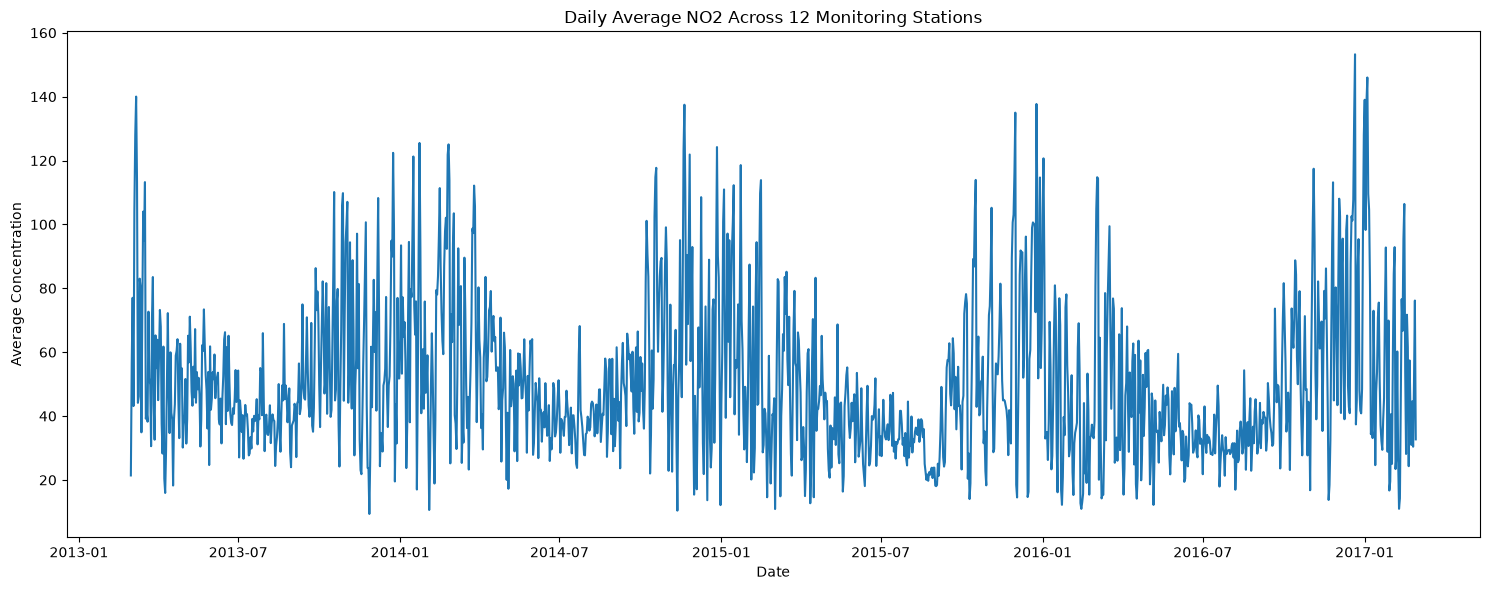

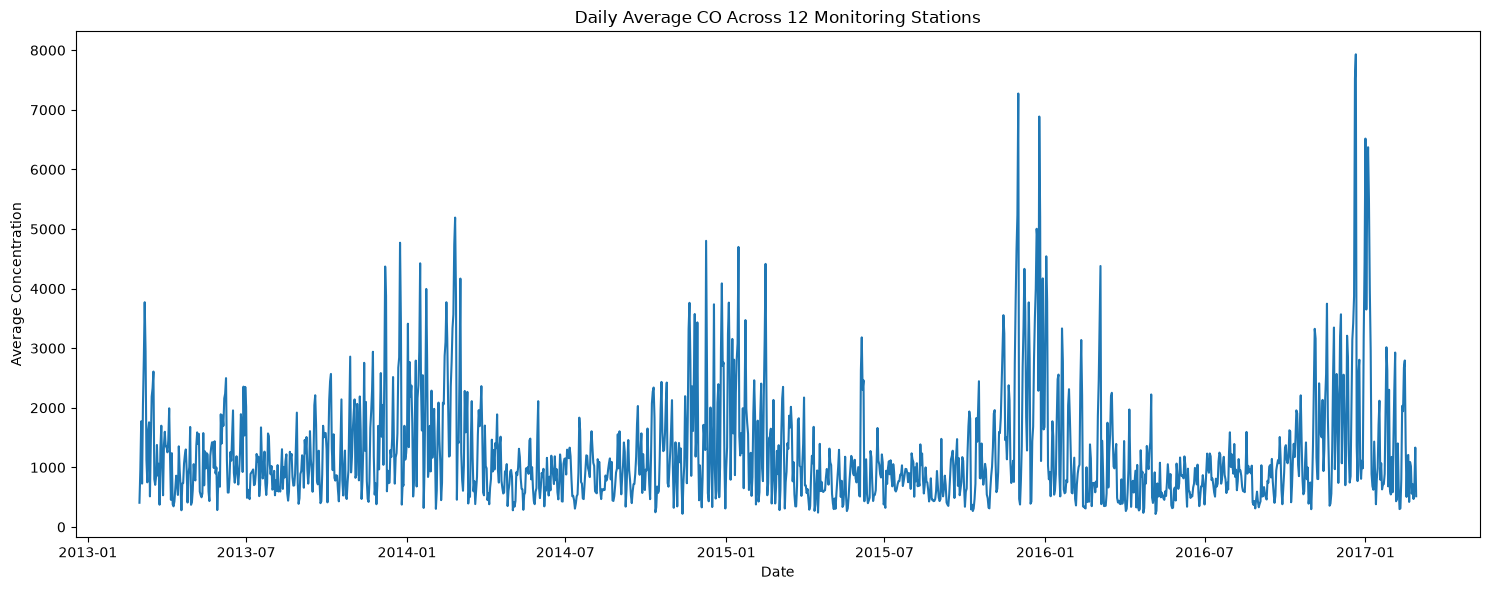

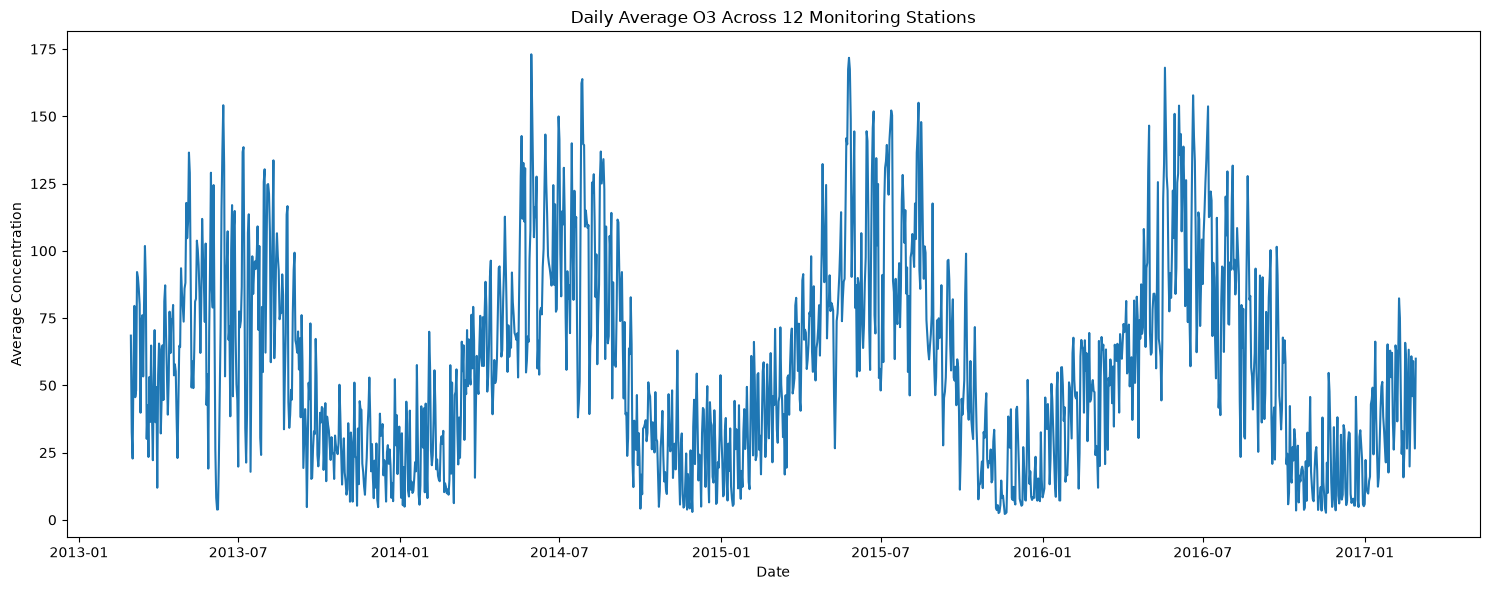

In [ ]:
for pollutant in pollutants:
    plt.figure(figsize=(15, 6))
    
    plt.plot(
        daily_pollutants.index,
        daily_pollutants[pollutant]
    )
    
    plt.title(f"Daily Average {pollutant} Across 12 Monitoring Stations")
    plt.xlabel("Date")
    plt.ylabel("Average Concentration")
    plt.tight_layout()
    plt.show()

### Analysis

The daily trend shows that pollutant concentrations went up and down throughout the study period. Peaks indicate periods when the average concentration increased, while lower values indicate periods of reduced concentration.

The patterns may be influenced by factors such as weather conditions, seasonal changes, and local pollution sources.